In [23]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm
import math
import seaborn as sns

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True


In [24]:
# The yahoo api is payed so lets instead use another free api to get the stock data i used stooq, you just need a free apikey from https://stooq.com/q/d/?s=aapl.us
APIKEY = "COa2gJQuK0X1c4DihNGzTxIFH8pf3Md7"

def get_aapl_prices():
    url = f"https://stooq.com/q/d/l/?s=aapl.us&i=d&apikey={APIKEY}"
    data = pd.read_csv(url)
    data["Date"] = pd.to_datetime(data["Date"])
    data = data.sort_values("Date")
    return data.set_index("Date")["Close"]

#set the stock prices we got equal to a variable
all_prices = get_aapl_prices()

#select only the prices for the timeframe which was asked for the project
prices = all_prices.loc["2020-01-01":"2026-04-30"]

#lets see the amount of loaded prices from the start date to the end date
print("Loaded", len(prices), "daily prices from", prices.index[0].date(), "to", prices.index[-1].date())


Loaded 1590 daily prices from 2020-01-02 to 2026-04-30


Missing prices: 0
Missing log returns: 0


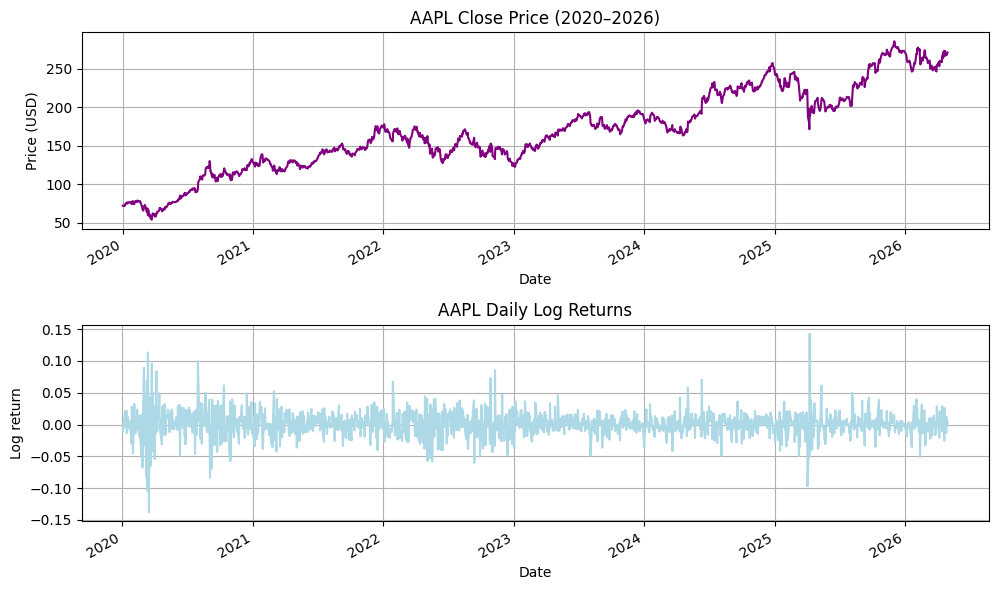

In [25]:
# compute daily log returns so we can plot them next to the price we do this because the binomial tree is defined on the log returns
# to do this e need to take the log of the price divded by the price of the previous day which de do with a shift
log_returns = np.log(prices / prices.shift(1)).dropna() # The first row is NA becuse there is no S0_t-1 so we have a dropna() to remove this one problematic row

# Even before printing i want to make sure that there are no missing values because I've had difficulty in the past with this
print("Missing prices:", prices.isna().sum())
print("Missing log returns:", log_returns.isna().sum())

#Lets make a plot for apple stock closing prices and the log returns
fig, axes = plt.subplots(2, 1, figsize=(10, 6))
prices.plot(ax=axes[0], title="AAPL Close Price (2020–2026)", color="purple")
axes[0].set_ylabel("Price (USD)")
log_returns.plot(ax=axes[1], title="AAPL Daily Log Returns", color="lightblue")
axes[1].set_ylabel("Log return")
plt.tight_layout()
plt.show()


In [26]:
# Lets start by determining the parameters which were stated in the assignment

# Maturity
T  = 0.5
# Number of binomial periods
n  = 25
#change in time for each period
dt = T / n
# Risk-free rate per annum
r  = 0.01
# Initial stock price on the first day which was specified by the timeframe in the assignment (last day of the trading, first day of the simulation of option trading)
S0 = all_prices.loc["2026-04-28"]

# Now we need to define geometric Brownian Motion:

# The whole setup assumes that dSt​=μSt​dt+σSt​dWt which if you apply ito's lemma is the log price d(lnSt​)=(μ−21​σ2)dt+σdW

#the up (u) and down (d) factors and to do this we need the sigma daily volitity as described we can find an estimate by using our historical price data

#we compute the daily volitility 
sigma_daily = log_returns.std()

#then we need to rescale the daily volatility into the a per year quantity because this si the convetnion the model uses 
# assuming iid variance scales linearly with time so 250 days of variance is 250 * daily variance but volatilituy is the square root of variance
# the 250 per year was given by the assignment and is around the average number of trading days per year
sigma = sigma_daily * np.sqrt(250) 

# Now we compute u and d using the formula which is derived from matching bionomial tree to the brownian motion 

# e ^ sigma * sqrt(dt)
u = np.exp(sigma * np.sqrt(dt))
# e ^ -sigma * sqrt(dt) or 1/u
d = np.exp(-sigma * np.sqrt(dt))
#the formulas choose u and d so that one step of the binomial tree behaves statistically like one step of the continuous GMB model


# the probability of an up move was given by the assignment as 1/2
p = 0.5

# Before we move on lets so a sanity check to make sure all the variables look like something we would expect

print(f"T            = {T}")
print(f"n            = {n}")
print(f"r            = {r}")
print(f"S_0          = {S0:.2f} USD")
print(f"sigma_daily  = {sigma_daily:.6f}")
print(f"sigma_annual = {sigma:.6f}")
print(f"u            = {u:.6f}")
print(f"d            = {d:.6f}")
print(f"p            = {p}")


T            = 0.5
n            = 25
r            = 0.01
S_0          = 270.71 USD
sigma_daily  = 0.019784
sigma_annual = 0.312816
u            = 1.045232
d            = 0.956725
p            = 0.5


## Task (iv) — Risk-Neutral Probability

The brief gave us the **physical** probability $p = 1/2$ — how often nature actually rolls "up" vs "down". But we cannot price the option with $p$, because two people can disagree about $p$ yet they must agree on the price of the option (otherwise one can arbitrage the other). So the option price has to depend only on quantities everyone observes: $S_0, u, d, r$.

The **risk-neutral probability** $q$ is a synthetic probability chosen so that, under it, the discounted stock price is a martingale:

$$S_t = e^{-r\Delta t}\,\mathbb{E}^Q[S_{t+\Delta t}\mid\mathcal{F}_t]$$

Substituting the binomial dynamics ($S_{t+\Delta t} = S_t u$ with prob $q$, or $S_t d$ with prob $1-q$) and solving for $q$:

$$q = \frac{e^{r\Delta t} - d}{u - d}$$

The **Fundamental Theorem of Asset Pricing** (Chapter 2, slide 48) then tells us that the arbitrage-free price of any derivative is its discounted expected payoff under $Q$:

$$V_0 = e^{-rT}\,\mathbb{E}^Q[\text{payoff at }T]$$

That's the formula we'll apply by backward induction in Task (v). Two extra quantities we set up here:
- `disc = exp(-r·dt)` — one-period discount factor (saves recomputing $e^{-r\Delta t}$ at every node)
- `assert 0 < q < 1` — sanity check; if $q$ falls outside $(0,1)$ the no-arbitrage condition $d < e^{r\Delta t} < u$ has been violated.

In [27]:
# We have to use a probability measure for the option other than p because although p is how nature will move up and down people have different opintions on what p is and to properly price an option we need to know what the expected
# non-arbitrage value is inorder to do this we cant rely on anything subjective so we must make a probability measure which is derived from observables that everyone can see in this case r,dt, and sigma
#sigma is included in the formula through the derivations of u and d 
q = (np.exp(r * dt) - d) / (u - d)

# if q is outside (0,1) the model would admit to arbitrage and an assumption of modern markets is so arbitradge so lets make a sanity check on q to make sure everything is fine if something is wrong the program will crash
assert 0 < q < 1, f"q = {q:.4f} outside (0,1) — model admits arbitrage!"

print(f"q = {q:.6f}")
print(f"No-arbitrage check 0 < q < 1  → OK")


q = 0.491202
No-arbitrage check 0 < q < 1  → OK


In [28]:
# now is time for the fun part we have to define a function which applies the paramenters of 
def price_floating_asian(S0, sigma, r, T, n):
    # the first step is to define our varibales from the value of the given parameters
    dt   = T / n
    u    = np.exp(sigma * np.sqrt(dt))
    d    = np.exp(-sigma * np.sqrt(dt))
    q    = (np.exp(r * dt) - d) / (u - d)
    disc = np.exp(-r * dt)

    #the next step is to create the structure of our tree and every possible outcome which is done using states where each possible outcome gives birth to two child outcomes which are a summing cumulative product of S0 and u and d which we will then map values to in a later function
    #The tree need the shape list[dict[set]]:
        #state[t] is the dictionary at each time point
        #states[t][j] is the set of all reachable cumulative sums C at not (t,j)
    # we need to make a nexted path because the option is path dependent and we need to teen them seperate without having the number of of dictionaries explode which would be bad for our computing budget
    states = []
    
    # the tree has n transitions but n+1 time points: t = 0, dt, 2dt, ..., n·dt = T and we need a dict at every time point, so range is n+1,  don't forget t=0!
    for t in range(n + 1): 
        #for each of the steps we create a dictionary which is keyed by the number of up moves so far
        #values get filled by foward pass
        states.append({})
    #We also need to set the cumulative sum to S0 since only one price is recorded at t=0
    states[0][0] = {S0}

# now we need to define what happens at each time step above we made the time points but now we need what happens in the transition
# for every time t we need to spawn two children one with up move values and one with down move values
#Things to consider
    # we have to make sure to only read from t and only write into t+1 so we dont mess up any past nodes
    # use range(n) because here we are doing the transitions not the time points 
    for t in range(n):
        #now we have to loop over every up move so we iterates h through every kety strored in states[t]
        for j in list(states[t].keys()):
            #now on each iteration we set one specific up count value 0, then 1, then 2, ect. through states[t][j] which is a set containing every distinct cumulative sum through all paths that point to this state node
            c_set = states[t][j] #specified as value to avoid repeated hashing and for readability

            # we now have to compute the current stock price at each j in each t to do that we just nultiply S0 by the number of up moves and the up move value and the number of down moves and the down move value this value is path independent
            S_now = S0 * (u ** j) * (d ** (t - j))

            #we are now inside the t and j loop so now we are at a specific node where c_set is the set of all cummulative sums recorded at that node
            # in c_set are elements containing the path history that arrived at (t,j) on each pass c must be calculated as one specific float 
            for C in c_set:
                # now we need if j+1 (childs up count) is not already a key in states[t+1] (the dict for the next time level) then we need to cteate a new empty set at that key to store the C values 
                if (j + 1) not in states[t + 1]:
                    states[t + 1][j + 1] = set()
                #then we add the value of the the up move to the C value for the next time frame
                states[t + 1][j + 1].add(C + S_now * u)
                # We do the same thing for the down count but we have to remember not to change the up count so NO j+1 on the index and to use d instead of u
                if j not in states[t + 1]:
                    states[t + 1][j] = set()
                states[t + 1][j].add(C + S_now * d)

    # Now that we calulcuated the states we need to calculate the values
    values = []

    # we again make a dictionary at each time point +1
    for t in range(n + 1):
        values.append({})

    # now we acess each last time level n which have key values of j which includes all j values of (0->n) (all up moves, all down moves, and everything inbetweem)
    for j in states[n]:
        #then we compute the terminal value at the right most part of the tree from top to botoom and fill values for all S terminals at that time step n this is not S-now but S_t becuase is the terminal price at maturity
        S_T = S0 * (u ** j) * (d ** (n - j))
        #next we make an empty dictionary at this slot in values to map the cummulative sums to option values where each c is a key  and each payofff will be the value
        values[n][j] = {}

        #now we loop over every cumulative sum C which is one path history that reached (n,j)
        for C in states[n][j]:
            #now we can calculate the maturity at payooff for each node using the floating-strike asian call payoff formula
            payoff = S_T - C / (n + 1) #IN FINAL SUBMISSION HAVE DERIVATION OF FORMULA HERE

            #make sure negative payoffs are zero because call options can never have a negative payoff because you simply would not exercise option if you lose money jsut take max of payoff or 0
            payoff = max(payoff,0.0)
            #for each time frame acess each j key and then set the value equal to the payoff 
            values[n][j][C] = payoff

# So far we've built the full grid of reachable augmented states (t, j, C) in the
# forward pass and pinned down the option's payoff at every terminal node (t=n).
# All that's left is backward induction: take those terminal payoffs and roll them
# back through the tree, at each node computing the discounted risk-neutral
# expected value of its two children, until we collapse everything down to a single
# number at (t=0, j=0, C=S0) — the arbitrage-free option price today.

    # we start at n-1 for backword induction because n was already filled bye the termila payoffs and go all the way to 0, you must include -1 as the stop value because python does not include the stop value in the formula, the step must be -1 because we are counting backwards
    for t in range(n - 1, -1, -1):
        # fro every up count j at this time level we process every node 
        for j in states[t]:
            #compute the current stcok price at node which is path independnet so its outside the C loop
            S_now = S0 * (u ** j) * (d ** (t - j))
            #we now make an empty dictionary at this node to holde the C->V mappings
            values[t][j] = {}
            #now we loop through each c which is one sepciifc path history to get the value of the up child and the down child  because to compute the option value we need to know these two values which are filled in from the pervious loop
            for C in states[t][j]:
                #we have to get the values by accessing the dict at the next time level up, get the childs up count which is one more than the parents and inside that dict look up the entry for the childs cumulative sum
                #the childs cumulative sum is the cumalitive sum of the parent plus the price now times u or d respectivally
                V_up = values[t + 1][j + 1][C + S_now * u] 
                V_dn = values[t + 1][j    ][C + S_now * d]
                #now we have to use the formula that actually computes the option value at this node — the discounted risk-neutral expectation of the two children
                #V_t = disc * (q * V_up + (1-q) * V_dn) — derived from the replication argument
                #IN FINAL SUBMISSION HAVE DERIVATION OF FORMULA HERE
                # we then use the value the formula gave out and index it to the current time frame at the correct j count  in the slot for the cummulative sum
                values[t][j][C] = disc * (q * V_up + (1 - q) * V_dn)

    # we then have to return the abritrage free price of the option today which is just the first node of the backward inductuon and then we access the key for the first original parent value S0
    return values[0][0][S0] 

In [29]:
%%time
# now that we defined the function lets actually run it and also see how long it takes.

price_binomial = price_floating_asian(S0, sigma, r, T, n)

print(f"Binomial price at t=0 : {price_binomial:.4f} USD")


Binomial price at t=0 : 14.0418 USD
CPU times: user 2.57 s, sys: 190 ms, total: 2.76 s
Wall time: 2.71 s


In [30]:
#"Following common practice in option pricing sensitivity analysis (see e.g. Saltelli et al., 2008, for an overview of methods), we conduct a two-way scenario-based robustness check by varying the risk-free rate r and volatility σ over a discrete grid around their baseline values. Because we vary both parameters jointly on a 5×5 grid rather than one-at-a-time, we also capture interaction effects between r and σ."

# we first define some ranges of r around the r wich was used in the assignment of 1 as the x axis
r_grid     = [0.0, 0.005, 0.01, 0.015, 0.02]

#next we use some volatility values around around our basleine siqma as the y axis
sigma_grid = [sigma * 0.8, sigma * 0.9, sigma, sigma * 1.1, sigma * 1.2]

#we have to constuct a dataframe in which sigma is the index and the interest rate is the features 
results = pd.DataFrame(
    index=[f"{s:.4f}" for s in sigma_grid],
    columns=[f"{rr:.2%}" for rr in r_grid],
    dtype=float,
)
#noew e label the index and the coulms to help us visualize our data
results.index.name   = "sigma"
results.columns.name = "r"

#now we have to loop out option pricing over each interest rate at each sigma and we can use a nested for loop for that
for s_val in sigma_grid:
    for r_val in r_grid:
        price = price_floating_asian(S0, s_val, r_val, T, n)
        results.loc[f"{s_val:.4f}", f"{r_val:.2%}"] = price

print("Floating-strike Asian call price (USD):")
print(results.round(4))

Floating-strike Asian call price (USD):
r         0.00%    0.50%    1.00%    1.50%    2.00%
sigma                                              
0.2503  10.9841  11.1449  11.3070  11.4705  11.6353
0.2815  12.3545  12.5141  12.6748  12.8367  12.9997
0.3128  13.7240  13.8824  14.0418  14.2022  14.3636
0.3441  15.0925  15.2497  15.4078  15.5668  15.7267
0.3754  16.4599  16.6159  16.7728  16.9304  17.0888


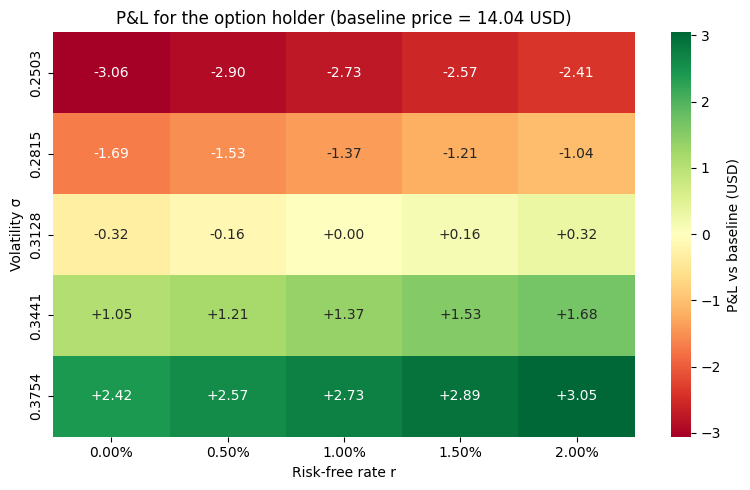

In [31]:
# lets print the results in a prettier table


baseline = results.loc[f"{sigma:.4f}", f"{r:.2%}"]
# P&L from the buyer's perspective: realized fair price minus what we paid at baseline
pnl = results - baseline

fig, ax = plt.subplots(figsize=(8, 5))
ax.grid(False)  # turn off the global rcParams grid so it doesnt draw lines through the heatmap cells
# RdYlGn: red for negative (loss), yellow near zero, green for profit — like a stock-market P&L heatmap
sns.heatmap(pnl, annot=True, fmt="+.2f", cmap="RdYlGn", center=0,
            cbar_kws={"label": "P&L vs baseline (USD)"}, ax=ax)
ax.set_title(f"P&L for the option holder (baseline price = {baseline:.2f} USD)")
ax.set_xlabel("Risk-free rate r")
ax.set_ylabel("Volatility σ")
plt.tight_layout()
plt.show()

In [32]:
# Not a required part of the assignment but as an extra sanity check for the model lets run a monte carlo simulation to see if our call option pricer actually worked

#We need a function that takes the same inputs as the option pricer and also a number of paths for random simulations and a seed for replicability
def monte_carlo_floating_asian(S0, sigma, r, T, n, n_sims=200_000, seed=42):
    
    # Set the random seed so we get the same result every run
    np.random.seed(seed)
    
    # Length of one time step
    dt = T / n
    
    # Pre-draw all the random numbers we need at once: one matrix of shape (n_sims, n)
    Z = np.random.standard_normal((n_sims, n))
    
    # Container for the payoff of each simulated path
    payoffs = np.zeros(n_sims)
    
    # Loop over each simulated path
    for i in range(n_sims):
        
        # Start the path at S0
        price_path = [S0]
        
        # Simulate n forward steps
        for t in range(n):
            # GBM log-return for this step (risk-neutral dynamics)
            log_return = (r - 0.5 * sigma**2) * dt + sigma * math.sqrt(dt) * Z[i, t]
            
            # New price = old price * exp(log_return)
            new_price = price_path[-1] * math.exp(log_return)
            price_path.append(new_price)
        
        # Average price along this path
        avg_price = sum(price_path) / len(price_path)
        
        # Terminal price is the last entry of the path
        terminal_price = price_path[-1]
        
        # Floating-strike Asian call payoff: max(S_n - average, 0)
        payoffs[i] = max(terminal_price - avg_price, 0)
    
    # Discounted expected payoff = Monte Carlo price estimate
    price = math.exp(-r * T) * payoffs.mean()
    
    # Standard error of the estimate
    se = math.exp(-r * T) * payoffs.std(ddof=1) / math.sqrt(n_sims)
    
    return price, se


# Run the Monte Carlo and compare with the binomial price 

mc_price, mc_se = monte_carlo_floating_asian(S0, sigma, r, T, n)

# 95% confidence interval
ci_lo = mc_price - 1.96 * mc_se
ci_hi = mc_price + 1.96 * mc_se

# Print results
print(f"Monte Carlo (200k paths) : {mc_price:.4f} USD")
print(f"  95% CI                 : [{ci_lo:.4f}, {ci_hi:.4f}]")
print(f"Binomial price           : {price_binomial:.4f} USD")
print(f"Absolute difference      : {abs(mc_price - price_binomial):.4f} USD")

Monte Carlo (200k paths) : 13.9071 USD
  95% CI                 : [13.8050, 14.0092]
Binomial price           : 14.0418 USD
Absolute difference      : 0.1346 USD


In [33]:
m1 = np.exp(r * dt)
m2 = q * u**2 + (1 - q) * d**2

ES = np.zeros(n + 1)
for t in range(n + 1):
    ES[t] = S0 * m1**t

cov_mat = np.zeros((n + 1, n + 1))
for s in range(n + 1):
    for t in range(n + 1):
        E_SsSt        = S0**2 * m2**min(s, t) * m1**abs(s - t)
        cov_mat[s, t] = E_SsSt - ES[s] * ES[t]

sum_ES = 0.0
for t in range(n + 1):
    sum_ES += ES[t]
E_Dn = ES[n] - sum_ES / (n + 1)

Var_Sn = cov_mat[n, n]

cov_Sn_sum = 0.0
for t in range(n + 1):
    cov_Sn_sum += cov_mat[n, t]

cov_total = 0.0
for s in range(n + 1):
    for t in range(n + 1):
        cov_total += cov_mat[s, t]

Var_Dn = Var_Sn - 2/(n+1) * cov_Sn_sum + cov_total / (n + 1)**2
sd_Dn  = np.sqrt(Var_Dn)

ratio        = E_Dn / sd_Dn
price_normal = np.exp(-r * T) * (E_Dn * norm.cdf(ratio) + sd_Dn * norm.pdf(ratio))

print(f"m_1                        = {m1:.6f}")
print(f"m_2                        = {m2:.6f}")
print(f"mu_D  (E[D_n])             = {E_Dn:.4f} USD")
print(f"sd_D  (sqrt(Var[D_n]))     = {sd_Dn:.4f} USD")
print()
print(f"Normal-approximation price = {price_normal:.4f} USD")
print(f"Binomial price             = {price_binomial:.4f} USD")
print(f"Absolute difference        = {price_normal - price_binomial:+.4f} USD")
print(f"Relative difference        = {(price_normal - price_binomial)/price_binomial:+.2%}")

m_1                        = 1.000200
m_2                        = 1.002358
mu_D  (E[D_n])             = 0.6790 USD
sd_D  (sqrt(Var[D_n]))     = 35.0456 USD

Normal-approximation price = 14.2519 USD
Binomial price             = 14.0418 USD
Absolute difference        = +0.2101 USD
Relative difference        = +1.50%


In [35]:
# Here starts the normal Approximation
# we compute expectations with the risk-neutral probability measure
# each one-step return (R_t := S_{t+1} / S_t) takes value u with the probabilities q and d = 1-q.
# There are two raw moments that appear constantly in everything below:

# m_1 = E^Q[R_t]   = q · u + (1 - q) · d
# m_2 = E^Q[R_t²]  = q · u² + (1 - q) · d²

# -------------------------------------------------------------------------------------------------------------------

m1 = q * u + (1 - q) * d                       # First raw moment of one step return
m2 = q * u**2 + (1 - q) * d**2                 # Second raw moment (E[R_t²])

# -------------------------------------------------------------------------------------------------------------------

# Under Q the returns per each step R_1, R_2, ..., R_t are i.i.d., so the expectation of the product factors is defined as:

#     E[S_t] = E[ S_0 · R_1 · R_2 · ... · R_t ]
#            = S_0 · E[R_1] · E[R_2] · ... · E[R_t]      (thanks to independence)
#            = S_0 · m_1^t                               (each R_i has mean m_1)

# -------------------------------------------------------------------------------------------------------------------
 
ES = np.zeros(n + 1)                           # we set vector ES = (E[S_0], E[S_1], ..., E[S_n])
for t in range(n + 1):                         # we loop over all n+1 steps t ∈ {0, 1, ..., n}
    ES[t] = S0 * m1**t                         # we apply E[S_t] = S_0 · m_1^t
 
# -------------------------------------------------------------------------------------------------------------------

# we will later compute Var(D_n) with Var(D_n) = a^T V a. (D_n = S_n − S̄_n) So we need to fill in every entry V[s, t] = Cov(S_s, S_t) for s, where t ∈ {0, ..., n}.
# We already know that Cov(X, Y) = E[XY] - E[X] E[Y], and since the means E[S_t] are already in hand from step B, the ingredient we still need is the cross-moment  E[S_s · S_t]  for every pair (s, t).
# If we try to do the direct computation of all pairs E[S_s · S_t] it would be a nighmare (summing over all 2^n paths).
# But there is a way to rewrite S_t in a way that exposes independent factors.  if we take two time-steps (s is one time step and t is another) and that we set s ≤ t , we can write:
# S_t = S_s · (S_t / S_s) 

# Why this rewriting?  Because the factor S_s only depends on returns within the window [0, s] while the factor S_t/S_s only depends on returns in the window [s, t].  
# Those two windows are DISJOINT, and returns in disjoint windows are independent under Q. 
# This independence lets us then factor the expectation:

#     E[S_s · S_t] = E[S_s · S_s · (S_t/S_s)]
#                  = E[S_s²] · E[S_t/S_s]                 (independence mentionned above)
#                  = (S_0² · m_2^s) · (m_1^(t-s))         (Each piece takes the same i.i.d.-product argument we used in the last step. In more details, firstly, E[S_s²] = S_0² · m_2^s —> we write S_s² = S_0² · R_1² · R_2² · ... · R_s²; in here, the R_i²'s are mutually independent (as R_i's are), so the expectation factors into s copies of E[R_i²] = m_2. ||| secondly, E[S_t / S_s] = m_1^(t−s) —> we write S_t/S_s = R_{s+1} · ... · R_t, a product of t−s independent returns each with mean m_1.)
#                  = S_0² · m_2^s · m_1^(t-s)


# So if we have arbitrary s, t (without setting s ≤ t) the symmetric shape is:

# E[S_s · S_t] = S_0² · m_2^min(s,t) · m_1^|t-s|       (★)


# From (★) we get the covariance:

#     Cov(S_s, S_t) = E[S_s S_t] - E[S_s] E[S_t]
#                   = S_0² · ( m_2^min(s,t) · m_1^|t-s|  -  m_1^(s+t) ).

# -------------------------------------------------------------------------------------------------------------------
 
V = np.zeros((n + 1, n + 1))                              # Create (n+1)×(n+1) covariance matrix
for s in range(n + 1):                                    # Outer loop: row index s ∈ {0, ..., n}
    for t in range(n + 1):                                # Inner loop: column index t ∈ {0, ..., n}
        E_SsSt  = S0**2 * m2**min(s, t) * m1**abs(s - t)  # (★) at indices (s, t)
        V[s, t] = E_SsSt - ES[s] * ES[t]                  # Cov(S_s, S_t) = E[S_s S_t] - E[S_s] E[S_t]

# -------------------------------------------------------------------------------------------------------------------

# In the last step we will compute Var(D_n) by using what we learnt in the lecture with the portfolio-variance formula:

#     Var(R_x) = x^T V x

# which applies to any linear combination of random variables ("x" is the vector of weights and "V" the covariance matrix of the underlying variables).
# So before we can use the formula we need to express D_n in exactly that shape: Σ (some weight) · (some S_t), with the weights gathered in a vector that we can then plug into the formula.

# but how we get it? The definition for D_n (which i remind you is the term we use for S_n − S̄_n) is:
# D_n = S_n - (1/(n+1)) · Σ_{t=0}^n S_t

# as you can see, the second term is already a linear combination of the S_t's. But the first term is outside the sum.  
# So we just distribute the 1/(n+1) across all the terms of the sum and then group by which S_t each piece multiplies:

#     D_n  =  S_n  -  S_0/(n+1)  -  S_1/(n+1)  -  …  -  S_n/(n+1)


# So:

#     coefficient on S_n   =   1 - 1/(n+1)     Notice on the formula sitting right above that one how S_n appears twice: once with coefficient +1 (the first term) and once with coefficient -1/(n+1). That's how we get the coefficient S_n.
#     coefficient on S_t   =   -1/(n+1)        this is for every t < n (see formula of D_n right above)

# Now if we call these coefficients a_t we get the form we need:

# D_n  =  Σ_{t=0}^n  a_t · S_t

# with

# a_n  =  1 - 1/(n+1)             <- terminal-price weight (large, positive)
# a_t  =  -1/(n+1)    for t < n   <- every earlier-price weight (small, negative)

# -------------------------------------------------------------------------------------------------------------------

a = np.full(n + 1, -1 / (n + 1))           # Initialize all coefficients to -1/(n+1)
a[n] = 1 - 1 / (n + 1)                     # Override the terminal coefficient to 1 - 1/(n+1)

# -------------------------------------------------------------------------------------------------------------------

# The base plan is to approximate D_n by a normal  N(μ_D, σ_D²) and then apply the Bachelier identity at the end to compute E[max(D_n, 0)].  
# But the Bachelier formula takes two inputs: the mean μ_D and the std σ_D of the normal.  
# Here, we now compute in this step the mean μ_D.

# We know from the lecture that:
#     μ_D = E[D_n] = Σ_t  a_t · E[S_t] = a^T · ES

# -------------------------------------------------------------------------------------------------------------------

mu_D = a @ ES     # μ_D = Σ_t a_t · E[S_t]   ("@" is the dot product in numpy)

# -------------------------------------------------------------------------------------------------------------------

# Now we compute the the standard deviation σ_D
# We learnt in the lectures the formula for the variance of a linear combination of correlated random variables, for weight vector x and covariance matrix V:

# Var(R_x) = x^T V x

# We apply it with x = a (from 2 steps above) and V = the full covariance matrix (we built in the 3rd step):

# σ_D²  :=  Var(D_n)  =  a^T V a

# this is one matrix-vector product which is followed by one dot product

# -------------------------------------------------------------------------------------------------------------------
 
var_D    = a @ V @ a                           # σ_D² = a^T V a (Chapter 5 formula applied to D_n)
sigma_D  = np.sqrt(var_D)                      # σ_D, the standard deviation of D_n

# -------------------------------------------------------------------------------------------------------------------

# we now must compute E[max(D_n, 0)]

# Everything until now was "exact" algebra.
# However, what we don't have is the full distribution of D_n. If we want to Compute it exactly, we would need to sum over all 2^n = 33 million paths, which we won't attempt.
# so we replace D_n's true (unknown, awkward) distribution with a normal that has the same first two moments. The mean and variance are exact. It's only the *shape* of the distribution is the approximation.

# D_n  ≈  N(μ_D, σ_D²)

# Now that we set up the approximation, we now need a closed form expression for E[max(X, 0)] when X ~ N(μ, σ²). 
# We use a piece of integral calculus that has been known since Bachelier's 1900 thesis on option pricing:

# E[max(X, 0)]  =  μ · Φ(μ/σ)  +  σ · φ(μ/σ)

# where Φ is the standard normal CDF and φ is its PDF.

# it's made of two terms:
#    -  μ · Φ(μ/σ)  is the "drift" contribution: the mean of D_n times the probability that D_n ends up positive.
#    -  σ · φ(μ/σ)  is the "diffusion" contribution: optionality value coming from the spread around the mean. The φ evaluated at μ/σ peaks when μ/σ is small.

# ------------------------------------------------------------------------------------------------------------------- 

z = mu_D / sigma_D                               # it's the standardized "moneyness" of the contract
expected_payoff  = mu_D * norm.cdf(z) + sigma_D * norm.pdf(z)
 
# ------------------------------------------------------------------------------------------------------------------- 

# Finally, the Fundamental Theorem of Asset Pricing states that the arbitrage free price today is the discounted expected payoff. Therefore:
# V_0  =  e^(-rT) · E^Q[ max(D_n, 0) ]

# We can plug that in the Bachelier approximation from previous step and it'll give us the closed-form normal-approximation price.

# ------------------------------------------------------------------------------------------------------------------- 
 
price_normal = np.exp(-r * T) * expected_payoff        # we discount the expected payoff back to t=0

# -------------------------------------------------------------------------------------------------------------------

print("=" * 64)
print("  NORMAL-APPROXIMATION PRICING — INTERMEDIATE QUANTITIES")
print("=" * 64)
print(f"  m_1                       = {m1:.6f}    (= e^(r·dt) = {np.exp(r*dt):.6f})")
print(f"  m_2                       = {m2:.6f}")
print(f"  E[S_n]                    = {ES[n]:.4f}  USD")
print(f"  μ_D  := E[D_n]            = {mu_D:.4f}  USD")
print(f"  σ_D  := √Var[D_n]         = {sigma_D:.4f}  USD")
print(f"  z    = μ_D / σ_D          = {z:.4f}")
print("-" * 64)
print(f"  Normal-approx. price      = {price_normal:.4f}  USD")
print(f"  Binomial price (Section 2)= {price_binomial:.4f}  USD")
print(f"  Absolute difference       = {price_normal - price_binomial:+.4f}  USD")
print(f"  Relative difference       = {(price_normal - price_binomial)/price_binomial:+.2%}")
print("=" * 64)

  NORMAL-APPROXIMATION PRICING — INTERMEDIATE QUANTITIES
  m_1                       = 1.000200    (= e^(r·dt) = 1.000200)
  m_2                       = 1.002358
  E[S_n]                    = 272.0669  USD
  μ_D  := E[D_n]            = 0.6790  USD
  σ_D  := √Var[D_n]         = 35.0456  USD
  z    = μ_D / σ_D          = 0.0194
----------------------------------------------------------------
  Normal-approx. price      = 14.2519  USD
  Binomial price (Section 2)= 14.0418  USD
  Absolute difference       = +0.2101  USD
  Relative difference       = +1.50%
